In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df1 = pd.read_csv(r"C:\Users\HP\Downloads\healthcare_LOS_Data\train_data_dictionary.csv")
df1

,Column,Description
0,case_id,Case_ID registered in Hospital
1,Hospital_code,Unique code for the Hospital
2,Hospital_type_code,Unique code for the type of Hospital
3,City_Code_Hospital,City Code of the Hospital
4,Hospital_region_code,Region Code of the Hospital
5,Available Extra Rooms in Hospital,Number of Extra rooms available in the Hospital
6,Department,Department overlooking the case
7,Ward_Type,Code for the Ward type
8,Ward_Facility_Code,Code for the Ward Facility
9,Bed Grade,Condition of Bed in the Ward


In [5]:
df2 = pd.read_csv(r"C:\Users\HP\Downloads\healthcare_LOS_Data\train_data.csv")
df2

,case_id,Hospital_code,Hospital_type_code,City_Code_Hospital,Hospital_region_code,Available Extra Rooms in Hospital,Department,Ward_Type,Ward_Facility_Code,Bed Grade,patientid,City_Code_Patient,Type of Admission,Severity of Illness,Visitors with Patient,Age,Admission_Deposit,Stay
0,1,8,c,3,Z,3,radiotherapy,R,F,2.0,31397,7.0,Emergency,Extreme,2,51-60,4911.0,0-10
1,2,2,c,5,Z,2,radiotherapy,S,F,2.0,31397,7.0,Trauma,Extreme,2,51-60,5954.0,41-50
2,3,10,e,1,X,2,anesthesia,S,E,2.0,31397,7.0,Trauma,Extreme,2,51-60,4745.0,31-40
3,4,26,b,2,Y,2,radiotherapy,R,D,2.0,31397,7.0,Trauma,Extreme,2,51-60,7272.0,41-50
4,5,26,b,2,Y,2,radiotherapy,S,D,2.0,31397,7.0,Trauma,Extreme,2,51-60,5558.0,41-50
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
318433,318434,6,a,6,X,3,radiotherapy,Q,F,4.0,86499,23.0,Emergency,Moderate,3,41-50,4144.0,11-20
318434,318435,24,a,1,X,2,anesthesia,Q,E,4.0,325,8.0,Urgent,Moderate,4,81-90,6699.0,31-40
318435,318436,7,a,4,X,3,gynecology,R,F,4.0,125235,10.0,Emergency,Minor,3,71-80,4235.0,11-20
318436,318437,11,b,2,Y,3,anesthesia,Q,D,3.0,91081,8.0,Trauma,Minor,5,11-20,3761.0,11-20


In [7]:
df2.shape

(318438, 18)

In [9]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 318438 entries, 0 to 318437
Data columns (total 18 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   case_id                            318438 non-null  int64  
 1   Hospital_code                      318438 non-null  int64  
 2   Hospital_type_code                 318438 non-null  object 
 3   City_Code_Hospital                 318438 non-null  int64  
 4   Hospital_region_code               318438 non-null  object 
 5   Available Extra Rooms in Hospital  318438 non-null  int64  
 6   Department                         318438 non-null  object 
 7   Ward_Type                          318438 non-null  object 
 8   Ward_Facility_Code                 318438 non-null  object 
 9   Bed Grade                          318325 non-null  float64
 10  patientid                          318438 non-null  int64  
 11  City_Code_Patient                  3139

In [17]:
df2.describe().T

,count,mean,std,min,25%,50%,75%,max
case_id,318438.0,159219.500000,91925.276847,1.0,79610.25,159219.5,238828.75,318438.0
Hospital_code,318438.0,18.318841,8.633755,1.0,11.00,19.0,26.00,32.0
City_Code_Hospital,318438.0,4.771717,3.102535,1.0,2.00,5.0,7.00,13.0
Available Extra Rooms in Hospital,318438.0,3.197627,1.168171,0.0,2.00,3.0,4.00,24.0
Bed Grade,318325.0,2.625807,0.873146,1.0,2.00,3.0,3.00,4.0
patientid,318438.0,65747.579472,37979.936440,1.0,32847.00,65724.5,98470.00,131624.0
City_Code_Patient,313906.0,7.251859,4.745266,1.0,4.00,8.0,8.00,38.0
Visitors with Patient,318438.0,3.284099,1.764061,0.0,2.00,3.0,4.00,32.0
Admission_Deposit,318438.0,4880.749392,1086.776254,1800.0,4186.00,4741.0,5409.00,11008.0


In [21]:
df2.dtypes

case_id                                int64
Hospital_code                          int64
Hospital_type_code                    object
City_Code_Hospital                     int64
Hospital_region_code                  object
Available Extra Rooms in Hospital      int64
Department                            object
Ward_Type                             object
Ward_Facility_Code                    object
Bed Grade                            float64
patientid                              int64
City_Code_Patient                    float64
Type of Admission                     object
Severity of Illness                   object
Visitors with Patient                  int64
Age                                   object
Admission_Deposit                    float64
Stay                                  object
dtype: object

In [23]:
df2.isnull().sum()

case_id                                 0
Hospital_code                           0
Hospital_type_code                      0
City_Code_Hospital                      0
Hospital_region_code                    0
Available Extra Rooms in Hospital       0
Department                              0
Ward_Type                               0
Ward_Facility_Code                      0
Bed Grade                             113
patientid                               0
City_Code_Patient                    4532
Type of Admission                       0
Severity of Illness                     0
Visitors with Patient                   0
Age                                     0
Admission_Deposit                       0
Stay                                    0
dtype: int64

In [27]:
#Understanding the TARGET VARIABLE i.e. STAY
df2['Stay'].value_counts().sort_index()

Stay
0-10                  23604
11-20                 78139
21-30                 87491
31-40                 55159
41-50                 11743
51-60                 35018
61-70                  2744
71-80                 10254
81-90                  4838
91-100                 2765
More than 100 Days     6683
Name: count, dtype: int64

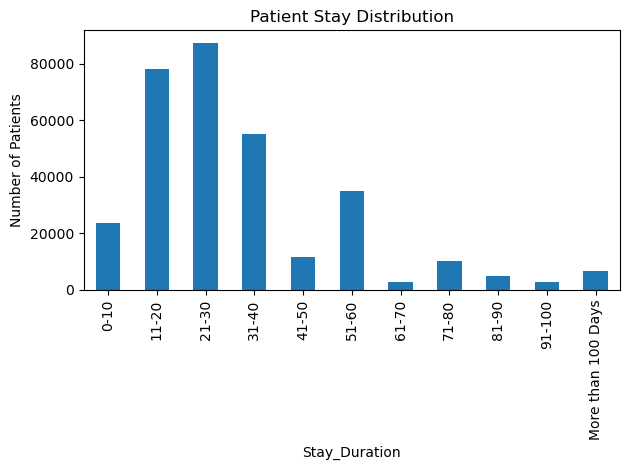

In [37]:
df2['Stay'].value_counts().sort_index().plot(kind = 'bar')
plt.title('Patient Stay Distribution')
plt.xlabel('Stay_Duration')
plt.ylabel('Number of Patients')
plt.tight_layout()
plt.show()

In [45]:
print(df2['Stay'].dtype)

object


In [55]:
print(df2['Stay'].unique())

['0-10' '41-50' '31-40' '11-20' '51-60' '21-30' '71-80'
 'More than 100 Days' '81-90' '61-70' '91-100']


In [57]:
more_than_30 = ['31-40', '41-50', '51-60', '61-70', 
                '71-80', '81-90', '91-100', 'More than 100 Days']

In [61]:
filtered = df2[df2['Stay'].isin(more_than_30)]
len(filtered)

129204

In [63]:
len(df2)

318438

In [69]:
percentage = (len(filtered)/len(df2)) * 100
percentage

40.57430331807134

In [75]:
percentage = (len(filtered)/len(df2)) * 100
print(f"Patients staying more than 30 days: {percentage:.2f}%")

Patients staying more than 30 days: 40.57%


In [83]:
# Data Cleaning
df2['Bed Grade'] = df2['Bed Grade'].fillna(df2['Bed Grade'].median())

In [85]:
df2['City_Code_Patient'] = df2['City_Code_Patient'].fillna(df2['City_Code_Patient'].mode()[0])

In [87]:
df2[['Bed Grade', 'City_Code_Patient']].isnull().sum()

Bed Grade            0
City_Code_Patient    0
dtype: int64

In [113]:
#Feature engineering:
stay_mapping = {
    '0-10'              : 5,
    '11-20'             : 15,
    '21-30'             : 25,
    '31-40'             : 35,
    '41-50'             : 45,
    '51-60'             : 55,
    '61-70'             : 65,
    '71-80'             : 75,
    '81-90'             : 85,
    '91-100'            : 95,
    'More than 100 Days': 110
}

df2['Stay_Days'] = df2['Stay'].map(stay_mapping)

In [127]:
sorted(df2['Age'].unique())

['0-10',
 '11-20',
 '21-30',
 '31-40',
 '41-50',
 '51-60',
 '61-70',
 '71-80',
 '81-90',
 '91-100']

In [131]:
age_mapping = {
    '0-10'              : 5,
    '11-20'             : 15,
    '21-30'             : 25,
    '31-40'             : 35,
    '41-50'             : 45,
    '51-60'             : 55,
    '61-70'             : 65,
    '71-80'             : 75,
    '81-90'             : 85,
    '91-100'            : 95
}

df2['Age_Mid'] = df2['Age'].map(age_mapping)

In [133]:
df2[['Age','Age_Mid']]

,Age,Age_Mid
0,51-60,55
1,51-60,55
2,51-60,55
3,51-60,55
4,51-60,55
...,...,...
318433,41-50,45
318434,81-90,85
318435,71-80,75
318436,11-20,15


In [135]:
severity_mapping = {
    'Minor'   : 1,
    'Moderate': 2,
    'Extreme' : 3
}
df2['Severity_Code'] = df2['Severity of Illness'].map(severity_mapping)

In [167]:
df2.head(5)

,case_id,Hospital_code,Hospital_type_code,City_Code_Hospital,Hospital_region_code,Available Extra Rooms in Hospital,Department,Ward_Type,Ward_Facility_Code,Bed Grade,...,Type of Admission,Severity of Illness,Visitors with Patient,Age,Admission_Deposit,Stay,Stay_Days,Age_Mid,Severity_Code,Long_Stay_Flags
0,1,8,c,3,Z,3,radiotherapy,R,F,2.0,...,Emergency,Extreme,2,51-60,4911.0,0-10,5,55,3,0
1,2,2,c,5,Z,2,radiotherapy,S,F,2.0,...,Trauma,Extreme,2,51-60,5954.0,41-50,45,55,3,1
2,3,10,e,1,X,2,anesthesia,S,E,2.0,...,Trauma,Extreme,2,51-60,4745.0,31-40,35,55,3,1
3,4,26,b,2,Y,2,radiotherapy,R,D,2.0,...,Trauma,Extreme,2,51-60,7272.0,41-50,45,55,3,1
4,5,26,b,2,Y,2,radiotherapy,S,D,2.0,...,Trauma,Extreme,2,51-60,5558.0,41-50,45,55,3,1


In [151]:
df2['Long_Stay_Flags'] = (df2['Stay_Days'] > 30).astype(int)

In [149]:
df2['Long_Stay_Flags']

0         0
1         1
2         1
3         1
4         1
         ..
318433    0
318434    1
318435    0
318436    0
318437    0
Name: Long_Stay_Flags, Length: 318438, dtype: int32

## Univariate Analysis
Analysing each column independently to understand the distribution and composition of the dataset.

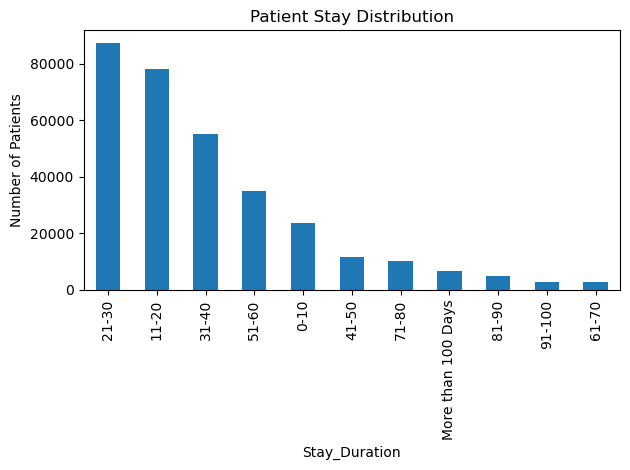

In [175]:
df2['Stay'].value_counts().plot(kind='bar')
plt.title('Patient Stay Distribution')
plt.xlabel('Stay_Duration')
plt.ylabel('Number of Patients')
plt.tight_layout()
plt.show()

- The 21-30 days bucket has the highest patient volume, followed by 11-20 and 31-40.
- Together these 3 buckets account for the majority of all admissions.
- This suggests most hospital stays fall in the 2-6 week window — 
  the critical planning period for bed management.

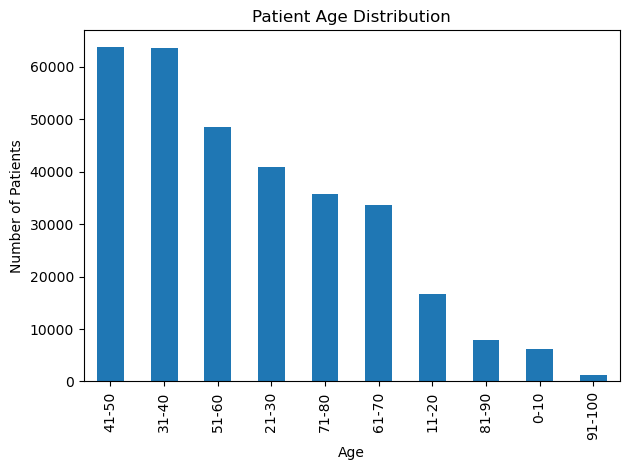

In [179]:
df2['Age'].value_counts().plot(kind='bar')
plt.title('Patient Age Distribution')
plt.xlabel('Age')
plt.ylabel('Number of Patients')
plt.tight_layout()
plt.show()

- The 41-50 age group is the largest patient segment, followed by 31-40 and 51-60.
- Working age adults (31-60) collectively dominate hospital admissions.
- This has insurance implications — this is the most economically active 
  population, making timely discharge critical.

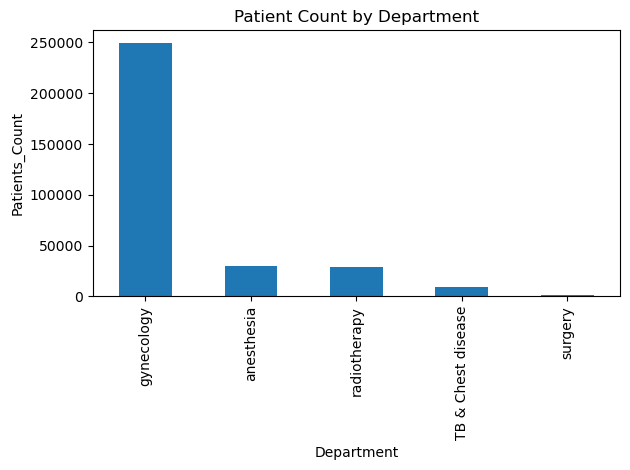

In [185]:
df2['Department'].value_counts().plot(kind='bar')
plt.title('Patient Count by Department')
plt.xlabel('Department')
plt.ylabel('Patients_Count')
plt.tight_layout()
plt.show()

- Gynecology overwhelmingly dominates with the highest patient count.
- Surgery has the lowest volume but do not ignore it — 
  low volume departments can still have high cost per patient.
- Resource allocation should be heavily weighted towards Gynecology.

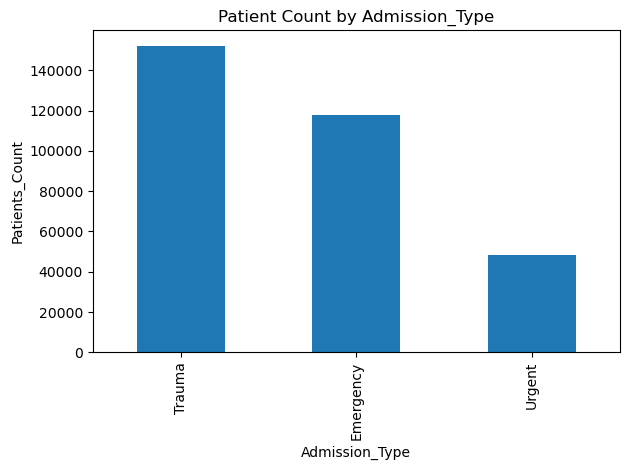

In [189]:
df2['Type of Admission'].value_counts().plot(kind = 'bar')
plt.title('Patient Count by Admission_Type')
plt.xlabel('Admission_Type')
plt.ylabel('Patients_Count')
plt.tight_layout()
plt.show()

- Trauma is the most common admission type, followed by Emergency.
- Planned/Urgent admissions are the least common.
- Since Trauma and Emergency together dominate, the hospital must 
  maintain high emergency readiness at all times.

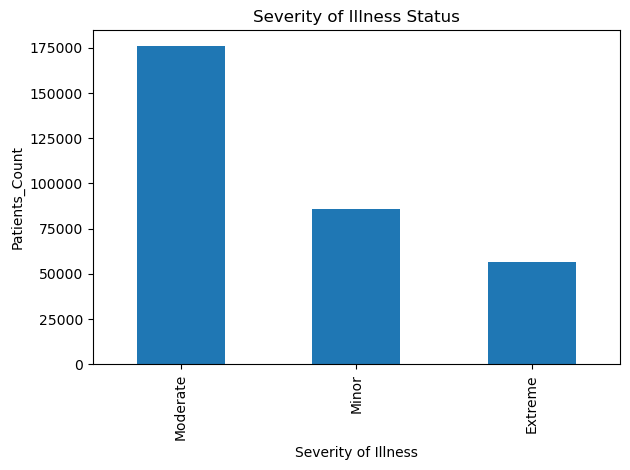

In [193]:
df2['Severity of Illness'].value_counts().plot(kind = 'bar')
plt.title('Severity of Illness Status')
plt.xlabel('Severity of Illness')
plt.ylabel('Patients_Count')
plt.tight_layout()
plt.show()

- Moderate severity is the most common, while Extreme is the least.
- This is a healthy sign — majority of cases are manageable.
- However Extreme cases, though fewer, will likely drive 
  disproportionately longer stays and higher costs.

## Summary — Univariate Analysis
- Core patient segment: Working age adults (31-60)
- Most common stay: 21-30 days
- Dominant department: Gynecology
- Admission mostly via Trauma and Emergency
- Majority of cases are Moderate severity

## Bivariate Analysis

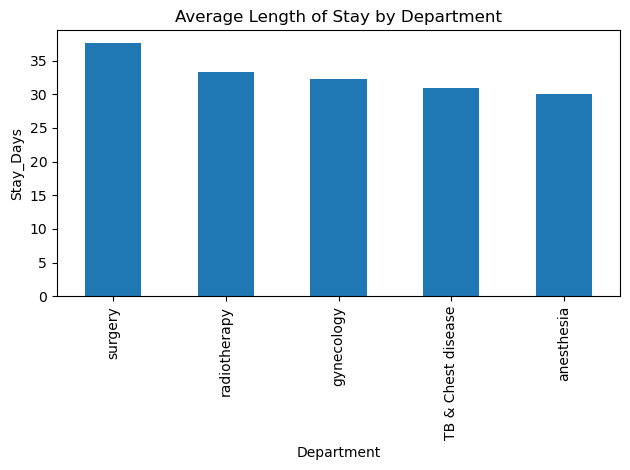

In [250]:
df2.groupby('Department')['Stay_Days'].mean().sort_values(ascending=False).plot(kind = 'bar')
plt.title('Average Length of Stay by Department')
plt.xlabel('Department')
plt.ylabel('Stay_Days')
plt.tight_layout()
plt.show()

Observation     : Surgery has the highest avg stay (~37 days) while 
                  Gynecology has the lowest despite having highest volume.
                  
Reason          : Surgery involves complex procedures requiring longer 
                  recovery and post-operative monitoring.
                  
Business Impact : Surgery patients generate the highest cost per admission 
                  for insurers despite being lowest in volume.
                  
Recommendation  : Hospital should prioritise dedicated discharge planning 
                  and post-operative care optimisation in Surgery department.

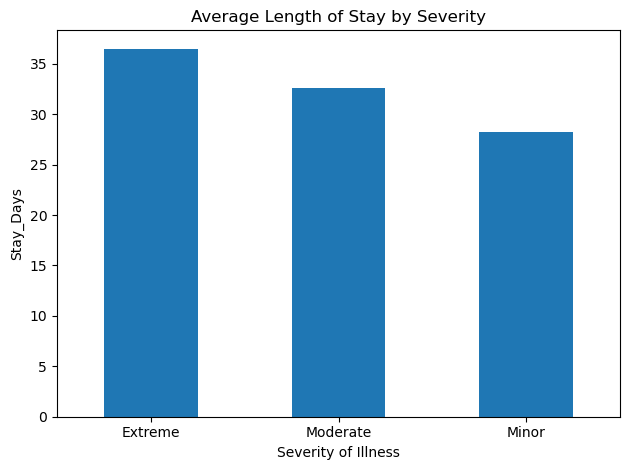

In [248]:
df2.groupby('Severity of Illness')['Stay_Days'].mean().sort_values(ascending=False).plot(kind = 'bar')
plt.title('Average Length of Stay by Severity')
plt.xlabel('Severity of Illness')
plt.ylabel('Stay_Days')
plt.xticks(rotation = 360)
plt.tight_layout()
plt.show()

Observation     : Extreme severity patients have the longest avg stay, 
                  followed by Moderate and Minor.
                  
Reason          : Severe illness requires intensive treatment, monitoring 
                  and longer recovery before safe discharge.
                  
Business Impact : Extreme severity cases are high cost flags for insurance 
                  companies — fewer in count but disproportionately expensive.
                  
Recommendation  : Insurers should apply higher claim reserves for patients 
                  admitted with Extreme severity at the time of admission itself.

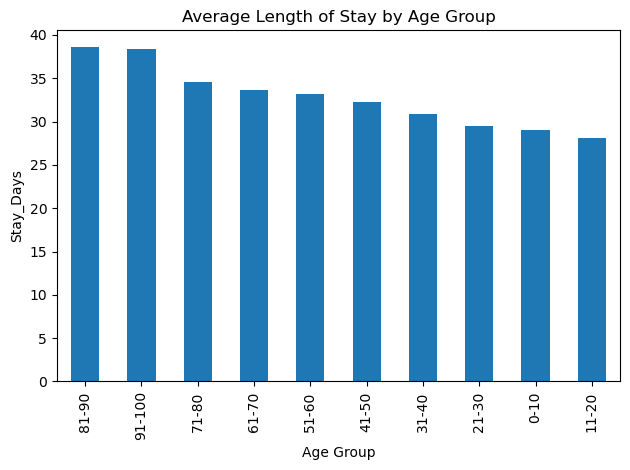

In [246]:
df2.groupby('Age')['Stay_Days'].mean().sort_values(ascending=False).plot(kind = 'bar')
plt.title('Average Length of Stay by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Stay_Days')
plt.tight_layout()
plt.show()

Observation     : Older age groups (81-90, 91-100) tend to have longer 
                  avg stays compared to younger patients.

Reason          : Elderly patients have weaker immunity, slower recovery 
                  and often have multiple conditions simultaneously.
    
Business Impact : Senior patients represent higher financial risk for both 
                  hospitals and insurance payers.
                      
Recommendation  : Hospitals should have dedicated elderly care protocols 
                  to manage and reduce extended stays in this segment.

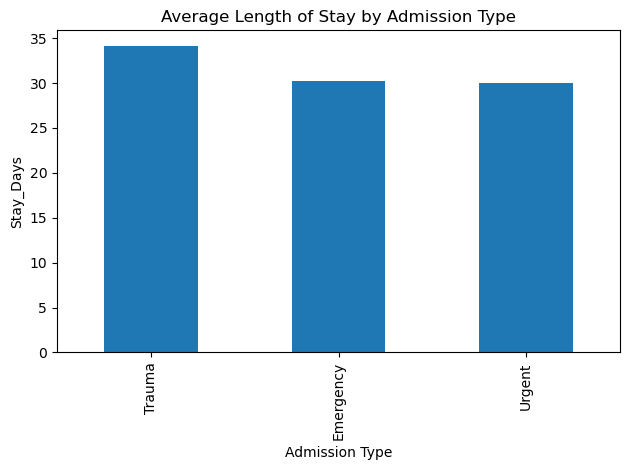

In [254]:
df2.groupby('Type of Admission')['Stay_Days'].mean().sort_values(ascending=False).plot(kind = 'bar')
plt.title('Average Length of Stay by Admission Type')
plt.xlabel('Admission Type')
plt.ylabel('Stay_Days')
plt.tight_layout()
plt.show()

Observation     : Trauma and Emergency admissions have higher avg stay 
                  compared to Urgent admissions.
                      
Reason          : Trauma and Emergency cases are unplanned and often 
                  more severe — requiring immediate and prolonged treatment.
                      
Business Impact : Since Trauma dominates admission volume AND has higher 
                  avg stay — it is the single biggest cost driver in this dataset.
                      
Recommendation  : Hospital must maintain strong emergency capacity and 
                  insurers must prioritise Trauma case management programs.

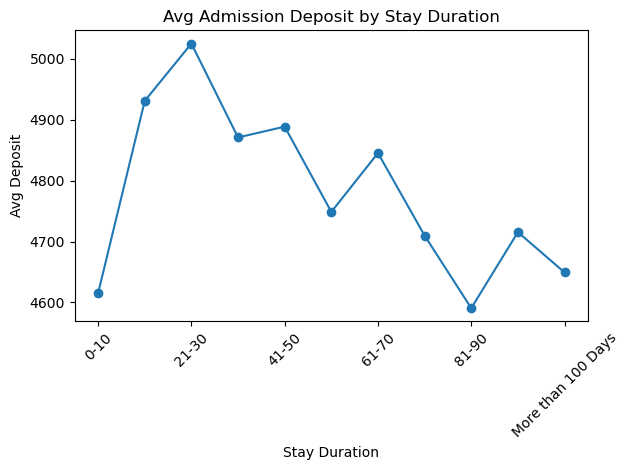

In [258]:
deposit_stay = df2.groupby('Stay')['Admission_Deposit'].mean()
deposit_stay.plot(kind='line', marker='o')
plt.title('Avg Admission Deposit by Stay Duration')
plt.xlabel('Stay Duration')
plt.ylabel('Avg Deposit')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Observation     : Admission deposit increases as stay duration increases.
    
Reason          : Hospitals likely collect higher deposits anticipating 
                  greater treatment costs for longer admissions.
                                         
Business Impact : Deposit amount at admission can serve as an early 
                  financial risk signal — higher deposit = potential long stay.
                                                        
Recommendation  : Insurance companies can use admission deposit as one 
                  input variable to estimate claim value at admission stage.

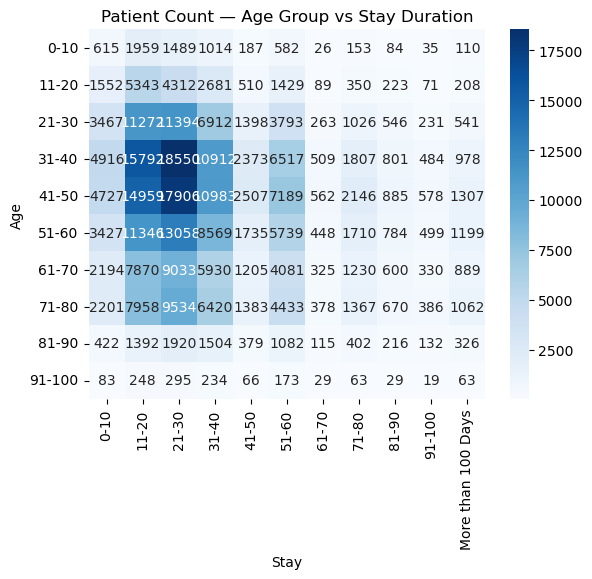

In [262]:
pivot = pd.crosstab(df2['Age'], df2['Stay'])
pivot
sns.heatmap(pivot, annot=True, fmt='d', cmap='Blues')
plt.title('Patient Count — Age Group vs Stay Duration')
plt.show()

Observation     : The 31-50 age group combined with 21-30 day stay 
                  is the darkest cell — highest patient concentration.
                  
Reason          : Working age adults are the dominant patient segment 
                  and most fall in the medium stay window.
                  
Business Impact : This is the core patient population hospitals and 
                  insurers must plan their capacity and budgets around.
                  
Recommendation  : Targeted wellness and preventive care programs for 
                  31-50 age group can reduce admission frequency and costs.

## Summary — Bivariate Analysis

- Surgery has highest avg LOS despite lowest patient volume → highest cost per case
- Extreme severity = longest stays → high financial risk for insurers
- Elderly patients (71+) stay longer → need dedicated care protocols  
- Trauma dominates both volume and avg stay → single biggest cost driver
- Admission deposit correlates with stay length → early financial risk indicator
- Working age adults (31-50) with 21-30 day stays = core hospital population

# Correlation Heatmap

In [287]:
numeric_cols = df2[['Stay_Days', 'Age_Mid', 'Admission_Deposit', 
                    'Severity_Code', 'Visitors with Patient', 
                    'Bed Grade']]
numeric_cols

,Stay_Days,Age_Mid,Admission_Deposit,Severity_Code,Visitors with Patient,Bed Grade
0,5,55,4911.0,3,2,2.0
1,45,55,5954.0,3,2,2.0
2,35,55,4745.0,3,2,2.0
3,45,55,7272.0,3,2,2.0
4,45,55,5558.0,3,2,2.0
...,...,...,...,...,...,...
318433,15,45,4144.0,2,3,4.0
318434,35,85,6699.0,2,4,4.0
318435,15,75,4235.0,1,3,4.0
318436,15,15,3761.0,1,5,3.0


In [291]:
correlation = numeric_cols.corr()
correlation

,Stay_Days,Age_Mid,Admission_Deposit,Severity_Code,Visitors with Patient,Bed Grade
Stay_Days,1.000000,0.094036,-0.052229,0.125790,0.541093,0.026885
Age_Mid,0.094036,1.000000,0.025182,0.125232,0.073795,0.001717
Admission_Deposit,-0.052229,0.025182,1.000000,-0.070892,-0.150358,0.073779
Severity_Code,0.125790,0.125232,-0.070892,1.000000,0.047292,-0.284407
Visitors with Patient,0.541093,0.073795,-0.150358,0.047292,1.000000,0.088920
Bed Grade,0.026885,0.001717,0.073779,-0.284407,0.088920,1.000000


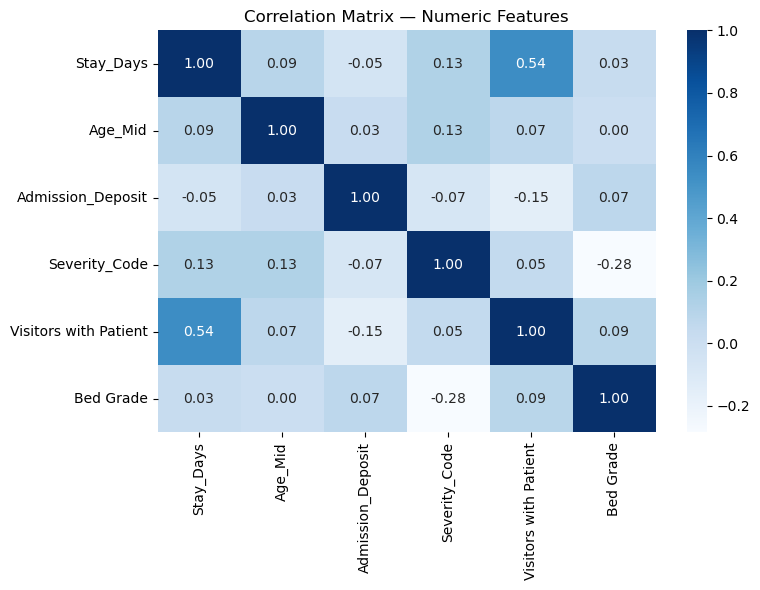

In [293]:
plt.figure(figsize=(8,6))
sns.heatmap(correlation, annot=True, fmt='.2f', cmap='Blues')
plt.title('Correlation Matrix — Numeric Features')
plt.tight_layout()
plt.show()

Observation     : Visitors with Patient has the strongest correlation 
                  with Stay_Days at 0.54 — far above all other features.
                  Severity and Age show weak positive correlations.
                  Admission Deposit shows near zero correlation.

Reason          : Number of visitors is likely a proxy for illness severity
                  — critical patients attract more family presence and 
                  also require longer treatment.

Business Impact : Visitor count at admission could be used as an early 
                  signal to flag potential long-stay patients.
                  
Surprise Finding: Admission Deposit has almost no correlation with Stay —
                  contradicting the trend seen in bivariate analysis.
                  This suggests deposit is set by hospital policy 
                  rather than actual clinical need.

In [300]:
df2.to_csv(r'C:\Users\HP\Downloads\healthcare_LOS_Cleaned.csv', index=False)
print('Cleaned data saved successfully!')

Cleaned data saved successfully!
